# Chapters 5 and 6: From messy data to a preprocessing pipeline

Can we predict whether someone likes a restaurant from their survey response? In this demo, our task is to predict a respondent’s “like” or “dislike” label from the rest of their restaurant survey response. This is a teaching example for preprocessing mixed data types, rather than a restaurant recommendation system. Comments may directly express the answer, so strong performance does not mean we can predict someone's preferences before a visit.

We already know how to fit and compare models. Today we will make that workflow work with missing values, different scales, categories, and text.

## Recall our machine learning workflow

1. Define the prediction problem and identify the inputs and target.
2. Reserve a test set before exploring the data.
3. Explore the training data and establish a dummy baseline.
4. Compare models using cross-validation on the training data.
5. Once choices are settled, refit on all training data and evaluate once on the test set.

**Discuss before starting:** where does preprocessing belong? What must be learned from training data only?

Our guiding rule: **each validation fold must stay unseen while both preprocessing and the model are fitted.** We will deliberately show two incorrect cross-validation examples, then repair them with pipelines. The test set stays reserved throughout this demo.

## Setup and imports

Run this notebook from `content/classes/varada`, with this directory's `.venv` selected as the kernel. From this directory you can also run:

```sh
uv run --locked jupyter lab lecture-05-06-preprocessing-demo.ipynb
```

The dataset is stored in `data/cleaned_restaurant_data.csv`. Run cells in order; commented-out failure examples are optional discussion exercises.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

%matplotlib inline

pd.set_option("display.max_colwidth", 200)


DATA_DIR = Path.cwd() / "data"
data_path = DATA_DIR / "cleaned_restaurant_data.csv"
if not data_path.is_file():
    raise FileNotFoundError(
        f"Dataset not found: {data_path}. Start the notebook from content/classes/varada."
    )

<br><br>

## Data and splitting

We will use the [restaurant survey data](data/cleaned_restaurant_data.csv). Each row describes one respondent's restaurant experience. The target is that respondent's reported `like` or `dislike` label, and the inputs are the other fields in their completed survey.

This task asks us to infer a satisfaction label from an existing response. Features such as comments and the assessment of the server describe an experience that has already happened. We are not estimating an intrinsic restaurant rating or learning an individual's preferences across visits.

Inferring satisfaction could be useful when comments are available but explicit ratings are missing. Here, the survey already collects the label, so the practical value is limited. We use it to learn how to preprocess mixed data types.

**Discuss:** could a model score well on this task without being useful for deciding where someone should eat next?

In [2]:
df = pd.read_csv(data_path)

In [3]:
# Reserve test rows before inspecting values or choosing cleaning rules.
train_df, test_df = train_test_split(df, test_size=0.2, random_state=123)
train_df.head()

,north_america,eat_out_freq,age,n_people,price,food_type,noise_level,good_server,comments,restaurant_name,target
934,Yes,4.0,21,30.0,30.0,Canadian/American,low,Yes,The building and the room gave a very comfy feeling. Immediately after sitting down it felt like we were right at home.,NaN,like
306,No,8.0,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dislike
918,Yes,2.0,23,80.0,40.0,Other,low,Yes,The food was amazing and was extremely unique!,Chambar Restaurant,like
568,Yes,3.0,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,like
684,No,5.0,22,3.0,12.0,Other,no music,Yes,Tonkatsu number one,Nori,like


### ❓❓ Questions for you

You have this restaurant dataset. Suppose you want to train a decision tree, KNN, or SVC to predict a respondent's reported satisfaction label from the other fields in their completed survey.

- Can we just call `fit` on the training data? If not, what hurdles would we face?


- Can the model handle NaNs directly?
- What to do with strings like *food_type*?  
- How to deal with free-form `comments`?  
- Do all models care if `price` and `age` are on different scales?  
- Should we keep `restaurant_name`?  
- Do we need to encode `like/dislike` as numbers?

| Challenge                  | Why is it a problem?                                                       | Examples from dataset                           |
|-----------------------------|----------------------------------------------------------------------------|------------------------------------------------|
| Missing values              | Many ML models in `sklearn` cannot handle NaNs directly                    | `price`, `food_type`, `noise_level`            |
| Categorical (string) data   | Models expect numeric input, not raw strings                               | `north_america`, `food_type`, `noise_level`    |
| Text features               | Free text must be vectorized before use                                    | `comments`                                     |
| Feature scaling             | Features on different scales can distort distance-based models (KNN, SVC)  | `age`, `price`, `n_people`, `eat_out_freq`     |
| High-cardinality features   | Can overfit or be uninformative if encoded naively                         | `restaurant_name`                              |
| Target encoding             | Sklearn allows categorical target labels                                   | `target` (`like` / `dislike`)                  |

- **Preprocessing** is about making the raw dataset ready for machine learning.

- We first need to figure out which transformations to apply on which features. 

In [4]:
train_df.describe()

,eat_out_freq,age,n_people,price
count,771.000000,771.000000,5.550000e+02,555.000000
mean,2.566550,23.906615,1.804252e+04,1835.646288
std,2.236869,4.408268,4.244753e+05,42446.209043
min,0.000000,10.000000,0.000000e+00,0.000000
25%,1.000000,21.000000,1.000000e+01,17.500000
50%,2.000000,22.000000,2.000000e+01,25.000000
75%,3.000000,26.000000,3.000000e+01,40.000000
max,15.000000,46.000000,1.000000e+07,1000000.000000


### Inspect training data and define the demo population

Which values look unusual? A high price is not automatically an error. For this exercise, we restrict the training examples to prices at most 200 and party sizes of at least one, keeping missing values for the imputation lesson. This is a teaching choice, not a general outlier-removal rule.

We leave the test set untouched. A final evaluation would need to state clearly whether it covers all responses or this restricted population.

In [5]:
upperbound_price = 200
lowerbound_people = 1
restaurant_df = train_df.loc[
    ~(train_df['price'] > upperbound_price)
    & ~(train_df['n_people'] < lowerbound_people)
].copy()
restaurant_df.shape

(755, 11)

In [6]:
restaurant_df.describe()

,eat_out_freq,age,n_people,price
count,755.000000,755.000000,539.000000,539.000000
mean,2.581536,23.916556,25.024119,33.346364
std,2.243054,4.427090,22.194087,28.230340
min,0.000000,10.000000,1.000000,0.000000
25%,1.000000,21.000000,10.000000,18.000000
50%,2.000000,22.000000,20.000000,25.000000
75%,3.000000,26.000000,30.000000,40.000000
max,15.000000,46.000000,200.000000,200.000000


Our target is the respondent's reported `like` or `dislike` label for this experience. We exclude `target` from the inputs and retain the other survey fields for our preprocessing exercises.

In [7]:
X_train = restaurant_df.drop(columns=['target']).copy()
y_train = restaurant_df['target'].copy()
X_test = test_df.drop(columns=['target']).copy()
y_test = test_df['target'].copy()

### A controlled teaching modification

We express training prices in cents to make the scale difference more visible. This changes units, not purchasing power. We also assign one training row a rare cuisine label so that a validation fold can contain a category absent from its fitting folds.

These are artificial examples, not data-cleaning recommendations. Any future test or deployment input would need the same price-unit conversion.

In [8]:
X_train['food_type'].value_counts()

food_type
Other                186
Canadian/American    122
Chinese              100
Indian                38
Italian               34
Mexican               20
Fusion                17
Thai                  16
fusion                 6
Name: count, dtype: int64

In [9]:
X_train.loc[X_train.index[0], 'food_type'] = 'Quebecois'
X_train['price'] = X_train['price'] * 100

In [10]:
# Check alignment after filtering training rows.
assert X_train.index.equals(y_train.index)
X_train.shape, X_test.shape

((755, 10), (193, 10))

<br><br>

## Exploratory data analysis 

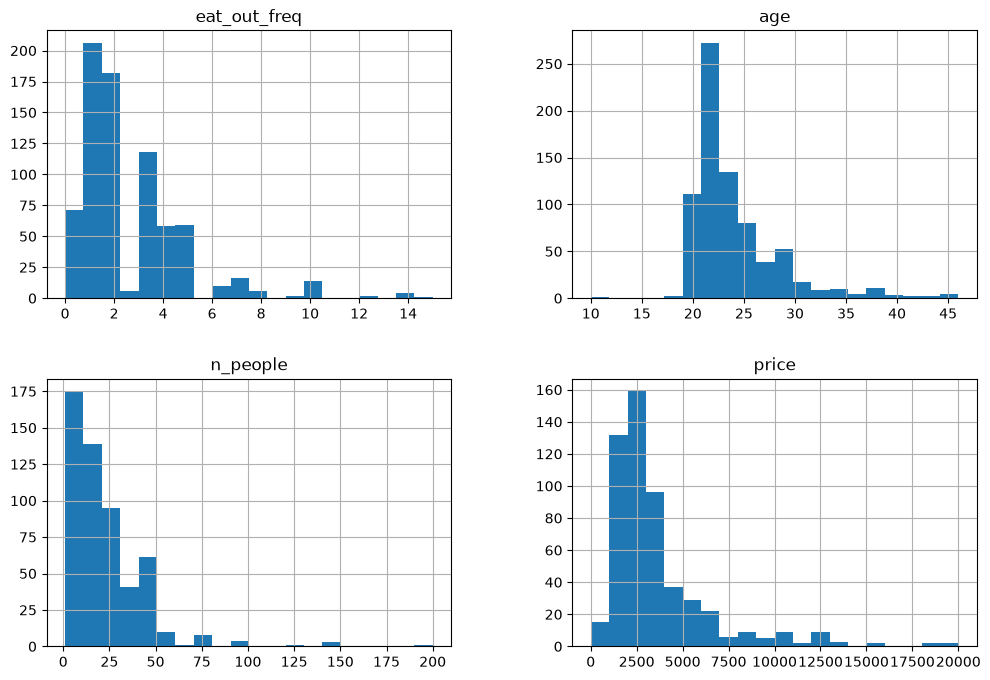

In [11]:
X_train.hist(bins=20, figsize=(12, 8));

Do you see anything interesting in these plots? 

In [12]:
X_train['food_type'].value_counts()

food_type
Other                186
Canadian/American    121
Chinese              100
Indian                38
Italian               34
Mexican               20
Fusion                17
Thai                  16
fusion                 6
Quebecois              1
Name: count, dtype: int64

Error in data collection? Probably "Fusion" and "fusion" categories should be combined?

In [13]:
# Apply a fixed spelling correction identified from training data.
X_train['food_type'] = X_train['food_type'].replace("fusion", "Fusion")

In [14]:
X_train['food_type'].value_counts()

food_type
Other                186
Canadian/American    121
Chinese              100
Indian                38
Italian               34
Fusion                23
Mexican               20
Thai                  16
Quebecois              1
Name: count, dtype: int64

Again, usually we should spend lots of time in EDA, but let's stop here so that we have time to learn about transformers and pipelines.   

<br><br>

## Modeling 

### Establish a dummy baseline

Before using the features, measure how well we can do by always predicting the most frequent training class. We use the same default five-fold classification splits for model comparisons below.

In `cross_validate`, `test_score` means the held-out **validation fold**, not our reserved test set.

In [15]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
scores = cross_validate(dummy, X_train, y_train, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.000546,0.000349,0.523179,0.518212
1,0.000285,0.000270,0.523179,0.518212
2,0.000268,0.000240,0.516556,0.519868
3,0.000253,0.000232,0.516556,0.519868
4,0.000251,0.000231,0.516556,0.519868


Compare the fold scores with the training target proportions below. What would a useful model need to improve on?

In [16]:
y_train.value_counts(normalize=True)

target
like       0.519205
dislike    0.480795
Name: proportion, dtype: float64

### Let's try KNN on this data

Do you think KNN would work directly on `X_train` and `y_train`?

In [17]:
# Preprocessing and pipeline
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
# knn.fit(X_train, y_train)

<br><br><br><br><br><br>
- We need to preprocess the data before feeding it into machine learning models. What are the different types of features in the data?
- What transformations are necessary before training a machine learning model?
- Can we categorize features based on the type of transformations they require?

In [18]:
X_train[4:11]

,north_america,eat_out_freq,age,n_people,price,food_type,noise_level,good_server,comments,restaurant_name
684,No,5.0,22,3.0,1200.0,Other,no music,Yes,Tonkatsu number one,Nori
97,Yes,2.0,26,25.0,3500.0,Italian,high,No,"seated at a very crowded area, didn't take our orders until 20 min later",NaN
864,No,3.0,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
779,Yes,5.0,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
848,Yes,1.0,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
392,Yes,2.0,22,30.0,2500.0,Other,high,Yes,temperature in the restaurant,Don't remember
883,Yes,2.0,26,45.0,3500.0,Chinese,medium,Yes,"Fresh food, great taste, great service, great value for money",Hotpot on Broadway


In [19]:
numeric_feats = ['age', 'n_people', 'price'] # Continuous and quantitative features
categorical_feats = ['food_type', 'north_america'] # Discrete and qualitative features
binary_feats = ['good_server'] # Categorical features with only two possible values 
ordinal_feats = ['noise_level'] # Some natural ordering in the categories 
noise_cats = ['no music', 'low', 'medium', 'high', 'crazy loud']
drop_feats = ['comments', 'restaurant_name', 'eat_out_freq'] # Omit these for now to focus on preprocessing; revisit comments later

In [20]:
X_train['north_america'].value_counts()

north_america
Yes                    404
No                     343
Don't want to share      8
Name: count, dtype: int64

In [21]:
X_train['good_server'].value_counts()

good_server
Yes    392
No     142
Name: count, dtype: int64

In [22]:
X_train.columns

Index(['north_america', 'eat_out_freq', 'age', 'n_people', 'price',
       'food_type', 'noise_level', 'good_server', 'comments',
       'restaurant_name'],
      dtype='str')

In [23]:
X_train['food_type'].value_counts()

food_type
Other                186
Canadian/American    121
Chinese              100
Indian                38
Italian               34
Fusion                23
Mexican               20
Thai                  16
Quebecois              1
Name: count, dtype: int64

In [24]:
X_train['north_america'].value_counts()

north_america
Yes                    404
No                     343
Don't want to share      8
Name: count, dtype: int64

In [25]:
X_train['good_server'].value_counts()

good_server
Yes    392
No     142
Name: count, dtype: int64

In [26]:
X_train['noise_level'].value_counts()

noise_level
medium        230
low           174
high           74
no music       41
crazy loud     20
Name: count, dtype: int64

<br><br>

### Start with numerical features

Let's build a KNN classifier using just `age`, `n_people`, and `price`. We will work through four steps:

1. Find the missing values.
2. Fill them using an imputer.
3. Scale the features so their units do not dominate distances.
4. Evaluate all these steps together using a pipeline.

For now, we use only training data. First we will inspect how the transformations work; then we will work out how to evaluate them correctly.

#### 1. Can KNN use these columns as they are?

These columns are numerical, but that does not mean they are ready for KNN. Inspect a few rows, then count the missing values in each column.

In [27]:
X_train_num = X_train[numeric_feats].copy()
X_train_num.head()

,age,n_people,price
934,21,30.0,3000.0
306,27,NaN,NaN
918,23,80.0,4000.0
568,22,NaN,NaN
684,22,3.0,1200.0


In [28]:
X_train_num.isna().sum()

age           0
n_people    216
price       216
dtype: int64

**Discuss:** how would KNN calculate a distance if one of the coordinates were missing?

KNN cannot fit data containing `NaN`. The commented line below is an optional failure example. We need to fill the missing values before fitting.

In [29]:
knn = KNeighborsClassifier()
# Optional: uncomment to see the missing-value error.
# knn.fit(X_train_num, y_train)

#### 2. Fill missing values with `SimpleImputer`

We will replace missing values with the median of their column. This involves two different operations:

- **`fit`:** learn one median per column from the fitting rows.
- **`transform`:** fill missing entries using those stored medians, leaving observed entries unchanged.

First, inspect the values the imputer learns. These medians come from all training rows for this demonstration of the mechanics; we have not started cross-validation yet.

In [30]:
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train_num)

pd.Series(imputer.statistics_, index=numeric_feats, name="Learned median")

age           22.0
n_people      20.0
price       2500.0
Name: Learned median, dtype: float64

In [31]:
X_train_num_imp = imputer.transform(X_train_num)

# Restore column names and row labels to inspect the returned array.
imputed_df = pd.DataFrame(
    X_train_num_imp, columns=numeric_feats, index=X_train_num.index
)
imputed_df.head()

,age,n_people,price
934,21.0,30.0,3000.0
306,27.0,20.0,2500.0
918,23.0,80.0,4000.0
568,22.0,20.0,2500.0
684,22.0,3.0,1200.0


In [32]:
# Every numerical column should now have zero missing values.
imputed_df.isna().sum()

age         0
n_people    0
price       0
dtype: int64

**Check your understanding:** if a new row has a missing price, do we calculate a new median or use the stored price median?

Use the stored median. New rows are transformed using what was learned during fitting.

KNN can now fit. The score below is **training accuracy**, so it only describes predictions on examples the model has already seen.

In [33]:
knn.fit(X_train_num_imp, y_train)
knn.score(X_train_num_imp, y_train)

0.6701986754966888

We have solved the missing-value problem. We have not yet measured generalization, and this training score is not a fair comparison with the dummy model's validation score. Before evaluating, there is one more issue with our distances.

#### 3. Put the numerical features on comparable scales

Earlier, we expressed price in cents. A price difference of 1,000 cents contributes much more to squared Euclidean distance than an age difference of 10 years. Changing currency units should not decide which neighbours matter most.

Inspect the ranges below. **Which feature could dominate distance before scaling?**

In [34]:
imputed_df.describe().loc[["mean", "std", "min", "max"]]

,age,n_people,price
mean,23.916556,23.586755,3095.852980
std,4.427090,18.884652,2414.320499
min,10.000000,1.000000,0.000000
max,46.000000,200.000000,20000.000000


`StandardScaler` subtracts each column's learned mean and divides by its learned standard deviation:

$$z = \frac{x - \mu}{\sigma}$$

It follows the same pattern as the imputer: **fit to learn, transform to apply**. We scale after imputation so we work with a complete numerical matrix.

In [35]:
scaler = StandardScaler()
scaler.fit(X_train_num_imp)
X_train_num_imp_scaled = scaler.transform(X_train_num_imp)

scaled_df = pd.DataFrame(
    X_train_num_imp_scaled, columns=numeric_feats, index=X_train_num.index
)
scaled_df.head()

,age,n_people,price
934,-0.659234,0.339826,-0.039728
306,0.696956,-0.190056,-0.246963
918,-0.207171,2.989234,0.374742
568,-0.433203,-0.190056,-0.246963
684,-0.433203,-1.090854,-0.785774


In [36]:
# On these fitting rows, means should be about 0 and standard deviations about 1.
pd.DataFrame({
    "mean": scaled_df.mean(),
    "std": scaled_df.std(ddof=0),
}).round(3)

,mean,std
age,-0.0,1.0
n_people,0.0,1.0
price,0.0,1.0


Negative values now mean "below the fitting-data mean", not negative ages or prices. Scaling changes the representation, not the original measurements.

**Discuss:** would converting dollars to cents still change these standardized values? Would scaling necessarily improve validation accuracy?

Both the imputer and scaler are **transformers**: they learn with `fit` and apply a transformation with `transform`. KNN is a **predictor**: it learns with `fit` and predicts labels with `predict`. All three are estimators.

#### 4. Evaluate the whole procedure

Our proposed procedure is now **impute $\to$ scale $\to$ fit KNN**. How should we cross-validate it?

The next cell is **deliberately incorrect**, even though it runs. Before running it, ask: which rows have already influenced the medians, means, and standard deviations?

In [37]:
# Incorrect evaluation: preprocessing was fitted before the CV folds were created.
leaky_cv_scores = cross_val_score(knn, X_train_num_imp_scaled, y_train, cv=5)
leaky_cv_scores

array([0.50993377, 0.52317881, 0.49006623, 0.53642384, 0.54304636])

Cross-validation splits the matrix it receives. Here, the imputer and scaler have already learned from **every training row**, including the rows that will become validation folds.

That leaks information across folds. The final test set is still separate, but each validation fold was supposed to be unseen too. The procedure is incorrect even if the effect on the scores is small.

**Repair it:** split into folds first; within each fold, fit the imputer, scaler, and KNN using only the fitting rows. Apply those learned transformations to the validation rows.

#### Let a pipeline keep the steps together

A pipeline packages the transformations and model into a single estimator. Pass the pipeline and the **raw numerical columns** to cross-validation. Each fold then fits a fresh copy of all three steps.

In [38]:
pipe_knn = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    KNeighborsClassifier(),
)
pipe_knn

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive est

In [39]:
pipe_knn.fit(X_train_num, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['dislike','like']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['age','n_people','price']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_

In [40]:
cross_val_score(pipe_knn, X_train_num, y_train)

array([0.49668874, 0.54304636, 0.49006623, 0.54304636, 0.53642384])

**Within each CV fold:**

| Step | Fitting rows | Validation rows |
|---|---|---|
| Imputer | Learn medians and fill missing entries | Fill using the stored medians |
| Scaler | Learn means/scales and standardize | Standardize using the stored means/scales |
| KNN | Fit on transformed rows | Predict and calculate accuracy |

The next comparison uses the same five-fold splits for the dummy baseline and numerical-feature KNN pipeline. Here, `test_score` means validation-fold accuracy, not a score on our reserved test set.

In [41]:
numeric_cv_results = cross_validate(
    pipe_knn, X_train_num, y_train, cv=5, return_train_score=True
)
dummy_numeric_cv_results = cross_validate(
    DummyClassifier(), X_train_num, y_train, cv=5, return_train_score=True
)

pd.DataFrame({
    name: {
        "Mean training accuracy": result["train_score"].mean(),
        "Mean validation accuracy": result["test_score"].mean(),
        "Validation accuracy std": result["test_score"].std(),
    }
    for name, result in {
        "Dummy baseline": dummy_numeric_cv_results,
        "Numerical KNN pipeline": numeric_cv_results,
    }.items()
}).T

,Mean training accuracy,Mean validation accuracy,Validation accuracy std
Dummy baseline,0.519205,0.519205,0.003244
Numerical KNN pipeline,0.660265,0.521854,0.023470


### Pause and connect the steps

- Does the numerical-feature pipeline improve on the dummy baseline on validation folds?
- Why did we pass `X_train_num`, rather than `X_train_num_imp_scaled`, to cross-validation?
- What gets learned again in each fold?

**Takeaway:** preprocessing is part of the model-fitting procedure. Cross-validate the whole pipeline, not just the final classifier.

We can now handle missing numerical values and different scales. Next, we will apply the same pattern to categorical features: choose a representation, inspect it, and put the transformation inside a pipeline.

<br><br>

### Categorical features: represent names without inventing an order

Would coding cuisines as 0, 1, 2 give KNN a meaningful distance? One-hot encoding gives each category its own indicator column.

We first inspect the representation, then put the encoder inside a pipeline. Watch for a category that appears only in a validation fold.

In [42]:
X_train['food_type'].value_counts()

food_type
Other                186
Canadian/American    121
Chinese              100
Indian                38
Italian               34
Fusion                23
Mexican               20
Thai                  16
Quebecois              1
Name: count, dtype: int64

In [43]:
X_train[categorical_feats]

,food_type,north_america
934,Quebecois,Yes
306,NaN,No
918,Other,Yes
568,NaN,Yes
684,Other,No
...,...,...
98,Mexican,No
322,NaN,Yes
382,Italian,No
365,NaN,No


In [44]:
X_train['north_america'].value_counts()

north_america
Yes                    404
No                     343
Don't want to share      8
Name: count, dtype: int64

In [45]:
X_train['food_type'].value_counts()

food_type
Other                186
Canadian/American    121
Chinese              100
Indian                38
Italian               34
Fusion                23
Mexican               20
Thai                  16
Quebecois              1
Name: count, dtype: int64

In [46]:
X_train_cat = X_train[categorical_feats]

In [47]:
ohe = OneHotEncoder(sparse_output=False)
X_train_cat_ohe = ohe.fit_transform(X_train_cat)

In [48]:
X_train_cat_ohe

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(755, 13))

This is a dense array because we set `sparse_output=False`. Most indicator entries are zero: why might sparse output save memory when there are many categories?

In [49]:
# Get the OHE feature names 

ohe_feats = ohe.get_feature_names_out().tolist()
ohe_feats

['food_type_Canadian/American',
 'food_type_Chinese',
 'food_type_Fusion',
 'food_type_Indian',
 'food_type_Italian',
 'food_type_Mexican',
 'food_type_Other',
 'food_type_Quebecois',
 'food_type_Thai',
 'food_type_nan',
 "north_america_Don't want to share",
 'north_america_No',
 'north_america_Yes']

In [50]:
pd.DataFrame(X_train_cat_ohe, columns = ohe_feats)

,food_type_Canadian/American,food_type_Chinese,food_type_Fusion,food_type_Indian,food_type_Italian,food_type_Mexican,food_type_Other,food_type_Quebecois,food_type_Thai,food_type_nan,north_america_Don't want to share,north_america_No,north_america_Yes
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
752,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [51]:
# Deliberately incorrect: the encoder saw all rows before CV split them.
cross_val_score(knn, X_train_cat_ohe, y_train)

array([0.54966887, 0.52980132, 0.49668874, 0.53642384, 0.49006623])

**Find the leak again:** which rows determined the encoder's vocabulary?

Now move encoding inside CV. What happens if a validation cuisine was absent from the fitting rows? `handle_unknown="ignore"` represents it with zeros in that feature's indicator columns.

Use an imputer and encoder inside the pipeline so missing-value handling and category learning both happen within each fitting fold.

In [52]:
# Code to create a pipeline for OHE and KNN
pipe_ohe_knn = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(sparse_output=False, handle_unknown="ignore"),
    KNeighborsClassifier()
)

In [53]:
cross_val_score(pipe_ohe_knn, X_train_cat, y_train)

array([0.54966887, 0.52980132, 0.49006623, 0.58940397, 0.50993377])

### Ordinal features: use a meaningful order

Noise levels have a natural order. We specify that order explicitly rather than letting alphabetical order decide it. Encoding levels as consecutive integers also imposes equal spacing for KNN: is that a reasonable simplification?

In [54]:
noise_ordering = ['no music', 'low', 'medium', 'high', 'crazy loud']

In [55]:
X_train['noise_level'].value_counts()

noise_level
medium        230
low           174
high           74
no music       41
crazy loud     20
Name: count, dtype: int64

In [56]:
pipe_ordinal_knn = make_pipeline(
    OrdinalEncoder(categories=[noise_ordering]),
    KNeighborsClassifier()
)

In [57]:
# Optional intentional failure: missing noise levels still need imputation.
# cross_val_score(pipe_ordinal_knn, X_train[["noise_level"]], y_train)

<br><br><br><br><br><br>

In [58]:
X_train['noise_level'].isnull().any()

np.True_

There are missing values. So we need an imputer. 

In [59]:
from sklearn.preprocessing import OrdinalEncoder
noise_ordering = ['no music', 'low', 'medium', 'high', 'crazy loud']

ordinal_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=[noise_ordering]),
    KNeighborsClassifier()
)

In [60]:
cross_val_score(ordinal_transformer, X_train[['noise_level']], y_train)

array([0.61589404, 0.56953642, 0.55629139, 0.55629139, 0.55629139])

<br><br><br><br>

### Combine the feature groups with `ColumnTransformer`

We have explored each feature type separately. Now apply the appropriate transformation to each group and join the resulting columns into one feature matrix. A `ColumnTransformer` handles the columns; an outer pipeline connects preprocessing to the classifier.

How can we horizontally stack  
- preprocessed numeric features, 
- preprocessed binary features, 
- preprocessed ordinal features, and 
- preprocessed categorical features?

Let's define a column transformer. 

In [61]:
from sklearn.compose import make_column_transformer

numeric_transformer = make_pipeline(SimpleImputer(strategy="median"),
                                    StandardScaler()) 
binary_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OneHotEncoder(drop="if_binary"))
ordinal_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OrdinalEncoder(categories=[noise_ordering]))
categorical_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OneHotEncoder(sparse_output=False, handle_unknown="ignore"))

# Define the column transformer
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_feats),
    (binary_transformer, binary_feats),
    (ordinal_transformer, ordinal_feats),
    (categorical_transformer, categorical_feats),    
    ("drop", drop_feats), 
    verbose_feature_names_out = False
)


How does the transformed data look like? 

In [62]:
categorical_feats

['food_type', 'north_america']

In [63]:
X_train.shape

(755, 10)

In [64]:
transformed = preprocessor.fit_transform(X_train)
transformed.shape

(755, 17)

In [65]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features p

Let's examine the feature names

In [66]:
preprocessor.get_feature_names_out()

array(['age', 'n_people', 'price', 'good_server_Yes', 'noise_level',
       'food_type_Canadian/American', 'food_type_Chinese',
       'food_type_Fusion', 'food_type_Indian', 'food_type_Italian',
       'food_type_Mexican', 'food_type_Other', 'food_type_Quebecois',
       'food_type_Thai', "north_america_Don't want to share",
       'north_america_No', 'north_america_Yes'], dtype=object)

Now let's examine the transformed data as a dataframe with these features. 

In [67]:
X_transformed = preprocessor.transform(X_train)
df_transformed = pd.DataFrame(
    X_transformed,
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index)
df_transformed

,age,n_people,price,good_server_Yes,noise_level,food_type_Canadian/American,food_type_Chinese,food_type_Fusion,food_type_Indian,food_type_Italian,food_type_Mexican,food_type_Other,food_type_Quebecois,food_type_Thai,north_america_Don't want to share,north_america_No,north_america_Yes
934,-0.659234,0.339826,-0.039728,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
306,0.696956,-0.190056,-0.246963,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
918,-0.207171,2.989234,0.374742,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
568,-0.433203,-0.190056,-0.246963,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
684,-0.433203,-1.090854,-0.785774,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,0.018861,-1.090854,-0.702880,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
322,-0.433203,-0.190056,-0.246963,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
382,0.244893,0.339826,2.861560,1.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
365,-0.433203,-0.190056,-0.246963,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


You can also examine the feature names of a particular pipeline in the column transformer.   

In [68]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features p

In [69]:
# Getting feature names from a column transformer
ohe_feat_names = preprocessor.named_transformers_['pipeline-4']['onehotencoder'].get_feature_names_out(categorical_feats).tolist()
ohe_feat_names

['food_type_Canadian/American',
 'food_type_Chinese',
 'food_type_Fusion',
 'food_type_Indian',
 'food_type_Italian',
 'food_type_Mexican',
 'food_type_Other',
 'food_type_Quebecois',
 'food_type_Thai',
 "north_america_Don't want to share",
 'north_america_No',
 'north_america_Yes']

The fit above was for inspecting the representation. For evaluation, pass **raw `X_train` and the full pipeline** to cross-validation. Cross-validation clones and refits the pipeline in each fold; do not pass the already transformed matrix.

Let's create a pipeline with the `preprocessor` and `SVC`. 

In [70]:
from sklearn.svm import SVC 

svc_all_pipe = make_pipeline(preprocessor, SVC()) # create a pipeline with column transformer. 
cross_val_score(svc_all_pipe, X_train, y_train).mean()

np.float64(0.6794701986754966)

Compare this validation accuracy with the earlier fold-safe models and the dummy baseline. We changed both the available features and the classifier, so a score difference cannot be attributed to preprocessing alone.

In each fold, the preprocessor learns only from fitting rows. It applies those learned transformations to validation rows, and SVC predicts their labels. The final test set has not influenced these comparisons.

### Incorporating text features

A comment such as “I loved the food” may directly express the satisfaction label we are trying to predict. Adding comments therefore brings this task closer to sentiment classification. Represent them as word counts and compare their cross-validation performance with the structured features.

For our stated task, the completed comment is available as an input. Its strong relationship with the label is not, by itself, leakage between training and validation folds. We still need to learn the word vocabulary within each fitting fold.

For a different task—predicting enjoyment before that same visit—the resulting comment would be unavailable. Past comments could help personalize future recommendations, but this demo does not build or evaluate that recommendation workflow.

**Pause:** if comments largely reveal the answer, what would high accuracy teach us about the model's practical usefulness?

In [71]:
X_train

,north_america,eat_out_freq,age,n_people,price,food_type,noise_level,good_server,comments,restaurant_name
934,Yes,4.0,21,30.0,3000.0,Quebecois,low,Yes,The building and the room gave a very comfy feeling. Immediately after sitting down it felt like we were right at home.,NaN
306,No,8.0,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
918,Yes,2.0,23,80.0,4000.0,Other,low,Yes,The food was amazing and was extremely unique!,Chambar Restaurant
568,Yes,3.0,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
684,No,5.0,22,3.0,1200.0,Other,no music,Yes,Tonkatsu number one,Nori
...,...,...,...,...,...,...,...,...,...,...
98,No,7.0,24,3.0,1400.0,Mexican,medium,No,NaN,NaN
322,Yes,1.0,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
382,No,3.0,25,30.0,10000.0,Italian,high,Yes,"Overly salted food, shells still in food",Robba di Matti
365,No,4.0,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's create bag-of-words representation of the `comments` feature. But first we need to impute the rows where there are no comments. There is a small complication if we want to put `SimpleImputer` and `CountVectorizer` in a pipeline. 
- `SimpleImputer` takes a 2D array as input and produced 2D array as output. 
- `CountVectorizer` takes a 1D array as input. 

To deal with this, we will use sklearn's `FunctionTransformer` to convert the 2D output of `SimpleImputer` into a 1D array which can be passed to `CountVectorizer` as input. 

In [72]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer

reshape_for_countvectorizer = FunctionTransformer(lambda X: X.ravel(), validate=False)
text_transformer = make_pipeline(SimpleImputer(strategy="constant", fill_value="missing"), 
                          reshape_for_countvectorizer, 
                          CountVectorizer(max_features=100, stop_words="english"))
text_pipe = make_pipeline(text_transformer, SVC())
cross_val_score(text_pipe, X_train[['comments']], y_train).mean()

np.float64(0.6384105960264901)

Compare text-only validation accuracy with the structured-feature model. Does combining them help on the same folds? If text performs well, consider whether it is simply an alternative expression of the survey's satisfaction label.

The next column transformer combines numerical, binary, categorical, ordinal, and text transformations. The vocabulary, like the medians and category lists, must be learned inside each fitting fold.

In [73]:
from sklearn.feature_extraction.text import CountVectorizer
text_feat = ['comments']

from sklearn.compose import make_column_transformer

numeric_transformer = make_pipeline(SimpleImputer(strategy="median"),
                                    StandardScaler()) 
binary_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OneHotEncoder(drop="if_binary"))
ordinal_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OrdinalEncoder(categories=[noise_ordering]))
categorical_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), 
                                    OneHotEncoder(sparse_output=False, handle_unknown="ignore"))

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_feats),
    (binary_transformer, binary_feats),    
    (categorical_transformer, categorical_feats),
    (ordinal_transformer, ordinal_feats),
    (text_transformer, text_feat)
)

In [74]:
preprocessor.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6369 stored elements and shape (755, 117)>

In [75]:
svc_num_cat_text_pipe = make_pipeline(preprocessor, SVC())
cross_val_score(svc_num_cat_text_pipe, X_train, y_train).mean()

np.float64(0.6966887417218542)

## Return to our workflow

Compare the combined model's cross-validation score with the text-only and structured-feature scores. More features do not guarantee better validation performance.

- **Split first:** reserve the test set before EDA and modeling decisions.
- **Explore and compare on training data:** use a dummy baseline and consistent CV splits.
- **Fit the whole pipeline in each fold:** medians, scales, categories, vocabulary, and classifier all learn from fitting rows only.
- **Evaluate once at the end:** after choosing a pipeline, refit it on all training data and evaluate on the reserved test set with the same input conventions, including price units and spelling corrections. State how the training-only population restriction affects that evaluation.

We stop at model comparison today, leaving the test set reserved.

**Return to the prediction problem:** these scores measure how well we recover a satisfaction label from a completed survey response. They do not establish that we can recommend restaurants or predict enjoyment before a visit. A model can score well on a task with limited practical value; defining a useful task matters as much as fitting the model.

**Exit question:** a colleague imputes and scales the full training set, then cross-validates an SVC. What would you change, and why?